<a href="https://colab.research.google.com/github/itsmanasa-dev/Student_Performance_Analysis/blob/main/Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Analysis

## Project Overview

This notebook performs an exploratory data analysis (EDA) and cleaning process on a dataset containing student performance information. The goal is to understand various factors influencing student performance, identify patterns, and prepare the data for further machine learning tasks or detailed reporting.

## Dataset

The dataset `student_performance_messy_data.csv` contains various attributes related to students, including:

*   **Demographic Information:** Student_ID, Student_Name, Gender, Age, City
*   **Academic Performance:** Department, Year, Assignment_Score, Internal_Marks, Final_Score, Grade, Pass_Fail
*   **Study Habits & Lifestyle:** Study_Hours_Per_Day, Attendance_Percentage, Sleep_Hours, Screen_Time_Hours, Commute_Time_Minutes, Extracurricular_Hours, Internet_Access, Internet_Quality, Study_Method, Stress_Level, Library_Books_Issued
*   **Financial & Placement:** Scholarship, Fees_Paid, Internship, Projects_Completed, Placement_Status, Starting_Salary_LPA
*   **Dates:** Enrollment_Date, Last_Exam_Date

## Analysis Performed

This notebook covers the following key data science steps:

1.  **Data Loading & Initial Inspection**: Loading the dataset into a Pandas DataFrame and performing initial checks (e.g., `df.info()`, `df.describe()`, checking for missing values).
2.  **Data Cleaning - Missing Values Handling**: Imputing missing values in numerical columns (e.g., `Age`, `Final_Score`) with the median and categorical columns (`Gender`, `Department`) with the mode. `Starting_Salary_LPA` missing values were filled with 0.
3.  **Data Transformation**: Creation of new features, such as `Study_Efficiency` (Final_Score / Study_Hours_Per_Day), and `Scaled_Study_Hours`. Also, categorizing students into `Performance_Category` using conditional logic.
4.  **Data Selection**: Demonstrations of various methods to select specific columns and filter rows based on conditions (e.g., high-scoring students).
5.  **Grouping and Aggregation**: Summarizing data by grouping it based on categorical features like `Department` and `Gender` to calculate statistics (e.g., mean `Final_Score`).
6.  **NumPy Operations**: Applied direct NumPy functions for statistical calculations and element-wise operations on DataFrame columns.
7.  **Data Visualization**: Using Matplotlib to create:
    *   A histogram of `Final_Score` to show its distribution.
    *   A scatter plot of `Study_Hours_Per_Day` vs. `Final_Score` to explore their relationship.
    *   A bar plot of `Mean Final Score by Department` to compare performance across departments.
8.  **Merging and Combining DataFrames**: Examples of how to combine different datasets using `pd.merge()` (inner and left joins) and `pd.concat()`.

## How to Use

1.  **Open in Google Colab:** You can open this notebook directly in Google Colab.
2.  **Run Cells:** Execute each code cell sequentially to reproduce the analysis. Ensure you have the `student_performance_messy_data.csv` file in your Colab environment or adjust the path in the first cell accordingly.
3.  **Explore and Modify:** Feel free to experiment with the code, change parameters, or add new analysis steps.

## Resources

*   [Pandas Documentation](https://pandas.pydata.org/docs/)
*   [NumPy Documentation](https://numpy.org/doc/)
*   [Matplotlib Documentation](https://matplotlib.org/stable/users/index.html)
*   [Google Colaboratory](https://colab.research.google.com/)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('student_performance_messy_data.csv')
print(df)


       Student_ID  Student_Name  Gender   Age               Department  \
0          108497   Vivek Gupta  Female  19.0              Electronics   
1          104047  Vivaan Mehta  Female  23.0         Computer Science   
2          108297    Vivaan Das  Female  22.0  Business Administration   
3          107360    Priya Iyer    Male  18.0         Computer Science   
4          110255   Meera Gupta    Male  17.0                 Commerce   
...           ...           ...     ...   ...                      ...   
12155      111965     Neha Iyer  Female  19.0   Information Technology   
12156      105192   Rohan Joshi  Female  25.0         Computer Science   
12157      105391    Kavya Nair  Female  17.0         Computer Science   
12158      100861    Karan Nair  Female  19.0         Computer Science   
12159      107271   Vivaan Iyer  Female  22.0  business administration   

             Year        City  Study_Hours_Per_Day  Attendance_Percentage  \
0        1st Year      Mumbai     

# **Mean**

In [6]:
mean_score=df['Final_Score'].mean()
print(f"Mean order price: {mean_score:.2f}")

Mean order price: 73.70


# **Median**

In [8]:
median_score=df['Final_Score'].median()
print(f"Mean order price: {mean_score:.2f}")
print(f"Median order price: {median_score:.2f}")
print(f"Gap (mean-median) {mean_score-median_score:.2f} -> Right-skew signal")

Mean order price: 73.70
Median order price: 73.74
Gap (mean-median) -0.04 -> Right-skew signal


# **Mode**

In [10]:
mode_category=df['Assignment_Score'].mode()[0]
print("Assignment Score:", mode_category)
df['Assignment_Score'].value_counts()

Assignment Score: 100.0


,count
Assignment_Score,
100.00,385
66.02,11
76.50,11
62.03,10
70.95,10
...,...
93.14,1
88.72,1
80.03,1


In [11]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

display(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))
df.info()

,Missing Count,Missing Percentage
Starting_Salary_LPA,8292,68.190789
Attendance_Percentage,181,1.488487
Internet_Quality,164,1.348684
Sleep_Hours,154,1.266447
Assignment_Score,140,1.151316
Internal_Marks,130,1.069079
Study_Method,123,1.011513
Gender,120,0.986842
Previous_GPA,112,0.921053
Department,102,0.838816


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12160 entries, 0 to 12159
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             12160 non-null  int64  
 1   Student_Name           12160 non-null  object 
 2   Gender                 12040 non-null  object 
 3   Age                    12079 non-null  float64
 4   Department             12058 non-null  object 
 5   Year                   12160 non-null  object 
 6   City                   12068 non-null  object 
 7   Study_Hours_Per_Day    12160 non-null  float64
 8   Attendance_Percentage  11979 non-null  float64
 9   Assignment_Score       12020 non-null  float64
 10  Internal_Marks         12030 non-null  float64
 11  Sleep_Hours            12006 non-null  float64
 12  Screen_Time_Hours      12160 non-null  float64
 13  Commute_Time_Minutes   12160 non-null  float64
 14  Previous_GPA           12048 non-null  float64
 15  Ex

In [12]:
display(df.describe())

,Student_ID,Age,Study_Hours_Per_Day,Attendance_Percentage,Assignment_Score,Internal_Marks,Sleep_Hours,Screen_Time_Hours,Commute_Time_Minutes,Previous_GPA,Extracurricular_Hours,Stress_Level,Projects_Completed,Final_Score,Starting_Salary_LPA,Library_Books_Issued
count,12160.000000,12079.000000,12160.000000,11979.000000,12020.000000,12030.000000,12006.000000,12160.000000,12160.000000,12048.000000,12160.000000,12160.000000,12160.000000,12160.000000,3868.000000,12160.000000
mean,105994.873602,21.056379,5.521761,77.714434,71.740047,67.593362,6.727166,5.411350,50.629112,7.203401,3.055547,5.028162,2.277303,73.698513,5.180651,8.008799
std,3466.206284,2.627548,2.107473,11.693713,14.778845,15.685909,1.245025,1.994325,25.134763,1.101740,1.851598,1.624506,1.523696,10.792743,1.673321,3.430223
min,100001.000000,-5.000000,-2.000000,-10.000000,-20.000000,-15.000000,-1.000000,1.000000,-30.000000,-2.000000,0.000000,-4.000000,0.000000,31.940000,2.400000,-60.000000
25%,102991.750000,19.000000,4.090000,69.720000,61.817500,56.960000,5.890000,4.070000,32.700000,6.460000,1.690000,3.940000,1.000000,66.437500,3.940000,6.000000
50%,105989.500000,21.000000,5.540000,77.940000,72.080000,67.775000,6.720000,5.380000,50.300000,7.200000,2.980000,5.030000,2.000000,73.740000,5.120000,8.000000
75%,109000.250000,23.000000,6.930000,85.985000,82.212500,78.507500,7.540000,6.720000,67.400000,7.950000,4.300000,6.122500,3.000000,80.950000,6.332500,10.000000
max,112000.000000,60.000000,30.000000,140.000000,150.000000,140.000000,20.000000,30.000000,500.000000,18.000000,10.960000,25.000000,8.000000,100.000000,11.520000,150.000000


In [18]:
# Numerical columns to impute with median
numerical_cols_to_impute = [
    'Age', 'Attendance_Percentage', 'Assignment_Score',
    'Internal_Marks', 'Sleep_Hours', 'Previous_GPA'
]

for col in numerical_cols_to_impute:
    if col in df.columns:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Missing values in '{col}' filled with median: {median_val}")
    else:
        print(f"Column '{col}' not found in DataFrame.")

Missing values in 'Age' filled with median: 21.0
Missing values in 'Attendance_Percentage' filled with median: 77.94
Missing values in 'Assignment_Score' filled with median: 72.08
Missing values in 'Internal_Marks' filled with median: 67.775
Missing values in 'Sleep_Hours' filled with median: 6.72
Missing values in 'Previous_GPA' filled with median: 7.2


/tmp/ipykernel_2228/4234503080.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [15]:
# Categorical columns to impute with mode
categorical_cols_to_impute = [
    'Gender', 'Department', 'City',
    'Internet_Quality', 'Study_Method'
]

for col in categorical_cols_to_impute:
    if col in df.columns:
        mode_val = df[col].mode()[0] # .mode() can return multiple values, take the first
        df[col].fillna(mode_val, inplace=True)
        print(f"Missing values in '{col}' filled with mode: {mode_val}")
    else:
        print(f"Column '{col}' not found in DataFrame.")

Missing values in 'Gender' filled with mode: Male
Missing values in 'Department' filled with mode: Computer Science
Missing values in 'City' filled with mode: Coimbatore
Missing values in 'Internet_Quality' filled with mode: Good
Missing values in 'Study_Method' filled with mode: Classroom


/tmp/ipykernel_2228/22824857.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


In [16]:
# Fill missing 'Starting_Salary_LPA' with 0
if 'Starting_Salary_LPA' in df.columns:
    df['Starting_Salary_LPA'].fillna(0, inplace=True)
    print("Missing values in 'Starting_Salary_LPA' filled with 0.")
else:
    print("Column 'Starting_Salary_LPA' not found in DataFrame.")

Missing values in 'Starting_Salary_LPA' filled with 0.


/tmp/ipykernel_2228/3770784217.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Starting_Salary_LPA'].fillna(0, inplace=True)


In [19]:
# Verify that all missing values have been handled
print("Total missing values after cleaning:", df.isnull().sum().sum())

Total missing values after cleaning: 0


In [25]:
# Select the 'Student_Name' column
student_names = df['Student_Name']
print("Type of selected column:", type(student_names))
print(student_names.head())

Type of selected column: <class 'pandas.core.series.Series'>
0     Vivek Gupta
1    Vivaan Mehta
2      Vivaan Das
3      Priya Iyer
4     Meera Gupta
Name: Student_Name, dtype: object


In [24]:
# Select 'Student_ID', 'Department', and 'Final_Score' columns
subset_df = df[['Student_ID', 'Department', 'Final_Score']]
print("Shape of selected DataFrame:", subset_df.shape)
print(subset_df.head())

Shape of selected DataFrame: (12160, 3)
   Student_ID               Department  Final_Score
0      108497              Electronics        71.93
1      104047         Computer Science        80.93
2      108297  Business Administration        56.42
3      107360         Computer Science        69.99
4      110255                 Commerce        58.39


In [22]:
# Select students with Final_Score > 90
high_scorers = df[df['Final_Score'] > 90]
print("Number of high scoring students:", len(high_scorers))
print(high_scorers.head())

Number of high scoring students: 824
    Student_ID    Student_Name   Gender   Age    Department        Year  \
16      100451   Vivaan Kapoor  Female   21.0      COMMERCE  Final Year   
55      105493  Priya Malhotra   Female  24.0   Electronics    3rd Year   
68      105172        Isha Das   Female  24.0   Electronics    2nd Year   
72      110624       Aman Nair   Female  23.0  Data Science  Final Year   
84      108026      Isha Patel     Male  22.0  Data Science    3rd Year   

       City  Study_Hours_Per_Day  Attendance_Percentage  Assignment_Score  \
16   Mysore                 7.33                  78.10             74.84   
55    delhi                 6.44                  85.02             79.62   
68  Chennai                 6.82                  88.80             94.53   
72    Delhi                 7.46                  88.72             95.30   
84   Mysore                 3.60                  86.31             96.27   

    ...  Enrollment_Date  Last_Exam_Date  Interns

In [21]:
# Group by 'Department' and calculate the mean of 'Final_Score'
department_scores = df.groupby('Department')['Final_Score'].mean().sort_values(ascending=False)
print("Mean Final Score by Department:")
print(department_scores)

Mean Final Score by Department:
Department
Business admin             77.019355
Information technology     74.807719
Electronics                74.807381
information technology     74.509194
data science               74.372857
Data Science               74.332000
business administration    74.321818
COMMERCE                   74.320702
Computer Science           74.266644
commerce                   74.143585
Data Science               73.824866
Electronics                73.758095
Information Technology     73.576378
Data science               73.569429
computer science           73.547692
electronics                73.461944
Commerce                   73.383793
Mechanical                 73.231225
Business Administration    73.220151
IT                         73.208723
mechanical                 72.908182
Mechanical                 72.557143
Computer science           72.447714
ELECTRONICS                71.661154
Computer Science           70.116129
Name: Final_Score, dtype: float6

In [20]:
# Group by 'Gender' and 'Placement_Status' and count students
gender_placement_counts = df.groupby(['Gender', 'Placement_Status']).size().unstack(fill_value=0)
print("Student Counts by Gender and Placement Status:")
print(gender_placement_counts)

Student Counts by Gender and Placement Status:
Placement_Status  Higher Studies  Looking for Job  Not Placed  Placed
Gender                                                               
 Female                       15               14          36      32
 Male                         13               20          42      28
 Other                         1                1           3       1
FEMALE                        10               14          33      40
Female                       681              919        2038    1713
Female                         9               16          27      24
MALE                          19               24          42      34
Male                         717              973        2099    1845
Male                          20               25          37      27
OTHER                          0                1           4       2
Other                         44               51         133     111
Other                          1           

In [27]:
# Calculate mean, standard deviation, min, and max of 'Final_Score' using NumPy
np_mean_final_score = np.mean(df['Final_Score'])
np_std_final_score = np.std(df['Final_Score'])
np_min_final_score = np.min(df['Final_Score'])
np_max_final_score = np.max(df['Final_Score'])

print(f"NumPy Mean of Final Score: {np_mean_final_score:.2f}")
print(f"NumPy Standard Deviation of Final Score: {np_std_final_score:.2f}")
print(f"NumPy Minimum Final Score: {np_min_final_score:.2f}")
print(f"NumPy Maximum Final Score: {np_max_final_score:.2f}")

NumPy Mean of Final Score: 73.70
NumPy Standard Deviation of Final Score: 10.79
NumPy Minimum Final Score: 31.94
NumPy Maximum Final Score: 100.00


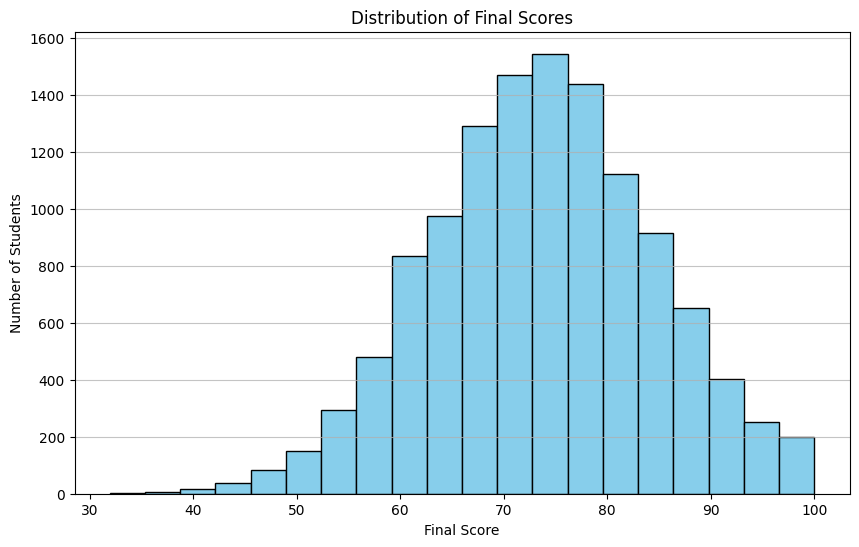

In [28]:
plt.figure(figsize=(10, 6))
plt.hist(df['Final_Score'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Final Scores')
plt.xlabel('Final Score')
plt.ylabel('Number of Students')
plt.grid(axis='y', alpha=0.75)
plt.show()

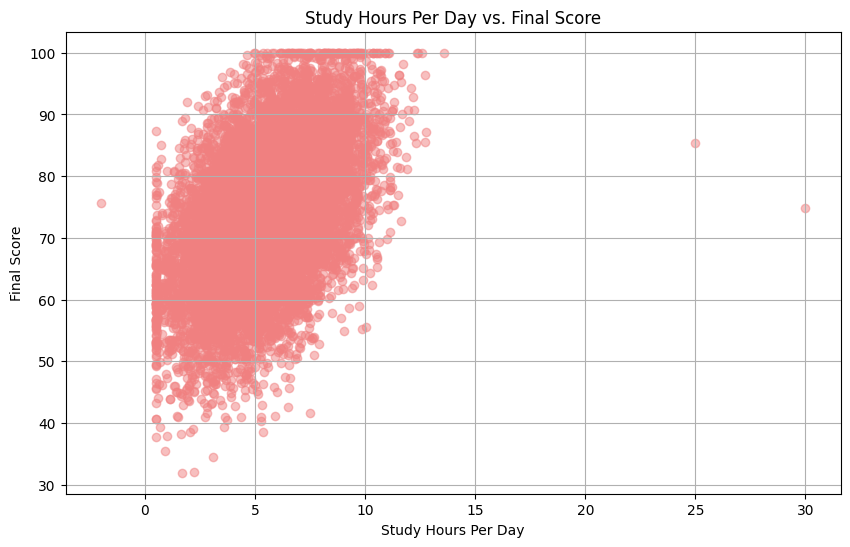

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Study_Hours_Per_Day'], df['Final_Score'], alpha=0.5, color='lightcoral')
plt.title('Study Hours Per Day vs. Final Score')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Final Score')
plt.grid(True)
plt.show()

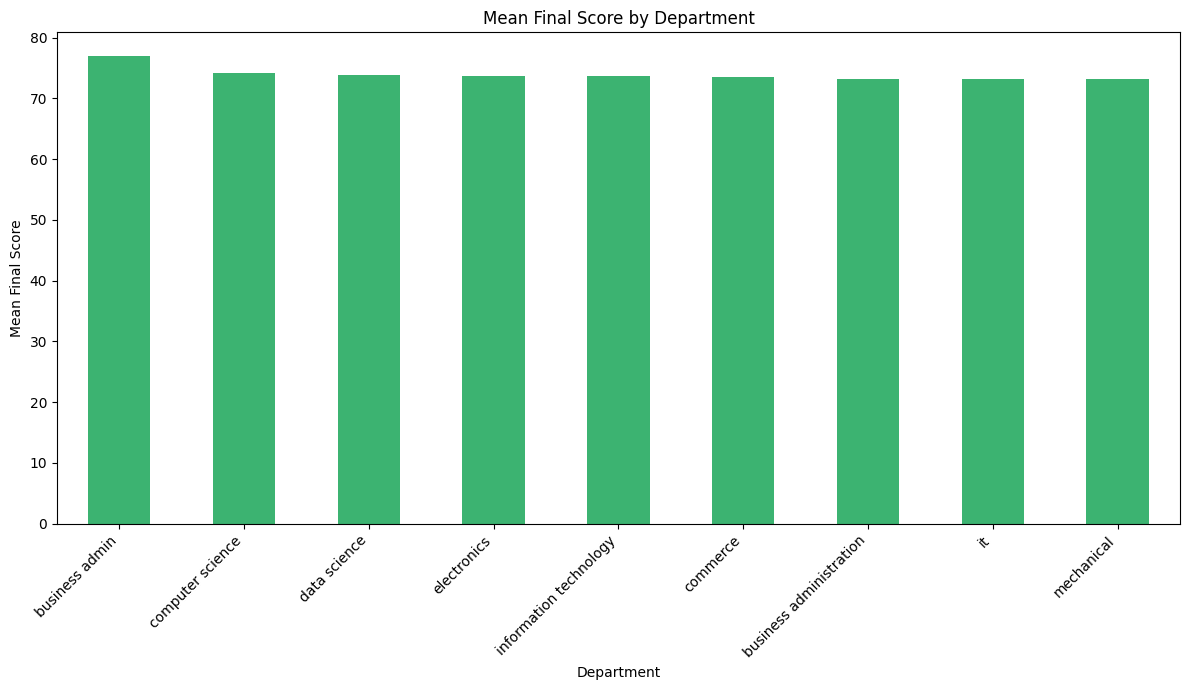

In [30]:
# First, re-calculate the mean final score by department (or use the existing 'department_scores' if it's clean)
# Note: Assuming 'Department' column might have inconsistent casing, let's normalize it for visualization.
df['Department_Cleaned'] = df['Department'].str.lower().str.strip()
mean_scores_by_dept = df.groupby('Department_Cleaned')['Final_Score'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
mean_scores_by_dept.plot(kind='bar', color='mediumseagreen')
plt.title('Mean Final Score by Department')
plt.xlabel('Department')
plt.ylabel('Mean Final Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [31]:
!git --version

git version 2.34.1


In [32]:
!git clone https://github.com/itsmanasa-dev/Student_Performance_Analysis.git

Cloning into 'Student_Performance_Analysis'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [37]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [35]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [36]:
%cd /content/Student_Performance_Analysis

/content/Student_Performance_Analysis


In [38]:
!git init

Reinitialized existing Git repository in /content/Student_Performance_Analysis/.git/


In [39]:
!git add .
!git commit -m "Update student performance analysis"
!git push origin main

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@7b3745caf68d.(none)')
fatal: could not read Username for 'https://github.com': No such device or address


In [40]:
!git config --global user.name "itsmanasa-dev"
!git config --global user.email "manasat433@gmail.com"

In [41]:
!git config --global --list

user.name=itsmanasa-dev
user.email=manasat433@gmail.com


In [42]:
!git add .
!git commit -m "Add student performance analysis"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [44]:
!ls -lh /content

total 2.4M
drwxr-xr-x 1 root root 4.0K Aug 18 13:44 sample_data
drwxr-xr-x 3 root root 4.0K Aug 20 05:06 Student_Performance_Analysis
-rw-r--r-- 1 root root 2.4M Aug 20 04:07 student_performance_messy_data.csv


In [45]:
!cp /content/student_performance_messy_data.csv /content/Student_Performance_Analysis/

In [46]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [47]:
!find /content/drive/MyDrive -name "Student_Performance_Analysis.ipynb"

/content/drive/MyDrive/Colab Notebooks/Student_Performance_Analysis.ipynb


In [48]:
!cp "/content/drive/MyDrive/Student_Performance_Analysis.ipynb" "/content/Student_Performance_Analysis/"

cp: cannot stat '/content/drive/MyDrive/Student_Performance_Analysis.ipynb': No such file or directory


In [49]:
!cp "/content/drive/MyDrive/Colab Notebooks/Student_Performance_Analysis.ipynb" "/content/Student_Performance_Analysis/"

In [50]:
!ls -lh /content/Student_Performance_Analysis

total 2.7M
-rw-r--r-- 1 root root   30 Aug 20 05:06 README.md
-rw------- 1 root root 272K Aug 20 05:22 Student_Performance_Analysis.ipynb
-rw-r--r-- 1 root root 2.4M Aug 20 05:18 student_performance_messy_data.csv


In [51]:
%cd /content/Student_Performance_Analysis
!git status

/content/Student_Performance_Analysis
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Student_Performance_Analysis.ipynb
	student_performance_messy_data.csv

nothing added to commit but untracked files present (use "git add" to track)


In [52]:
!git add Student_Performance_Analysis.ipynb student_performance_messy_data.csv

In [53]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   Student_Performance_Analysis.ipynb
	new file:   student_performance_messy_data.csv



In [54]:
!git commit -m "Add student performance analysis notebook and dataset"

[main 199d864] Add student performance analysis notebook and dataset
 2 files changed, 12162 insertions(+)
 create mode 100644 Student_Performance_Analysis.ipynb
 create mode 100644 student_performance_messy_data.csv


In [55]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [56]:
!gh --version

gh version 2.97.0 (2026-07-31)
https://github.com/cli/cli/releases/tag/v2.97.0


In [64]:
!gh auth login

78? Where do you use GitHub?  [Use arrows to move, type to filter]
> GitHub.com
  Other
7^C


In [65]:
!gh auth login --hostname github.com --git-protocol https --web

? Authenticate Git with your GitHub credentials? (Y/n) 7^C
